In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [137]:
df= pd.read_csv('./upl_goals_2019_2025_cleaned.csv')

In [138]:
df.head()

,Date,Time,Season,Match Day,home_team,away_team,goal_minute,team_side,player_name,goal_type,has_goal,goal_minute_num,in_added_time,match_id,round,match_half
0,2019-11-05,4:30 pm,2019/20,12,Kyetume FC,Busoga United FC,10,home,Noel Nasasira,Regular,1,10.0,0,UPL20/KYE/BUS/05-11,Round 1,First Half
1,2019-11-05,4:30 pm,2019/20,12,Kyetume FC,Busoga United FC,80,away,Dan Ssewava,Regular,1,80.0,0,UPL20/KYE/BUS/05-11,Round 1,Second Half
2,2019-11-05,4:30 pm,2019/20,12,Kyetume FC,Busoga United FC,90+2,home,Jonathan Mugabi,Regular,1,92.0,1,UPL20/KYE/BUS/05-11,Round 1,Second Half
3,2019-10-09,8:00 pm,2019/20,8,SC Villa,Wakiso Giants FC,55,home,Amir Kakomo,Regular,1,55.0,0,UPL20/SCV/WAK/09-10,Round 1,Second Half
4,2019-10-09,8:00 pm,2019/20,8,SC Villa,Wakiso Giants FC,74,home,David Owori,Regular,1,74.0,0,UPL20/SCV/WAK/09-10,Round 1,Second Half


In [139]:
df.shape

(3319, 16)

In [140]:
# normalize column names: strip whitespace, lowercase, replace spaces (and other whitespace) with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

In [141]:
# parse ISO-format dates (YYYY-MM-DD); coerce invalid formats to NaT
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
df['goal_minute_num'] = pd.to_numeric(df['goal_minute_num'], errors='coerce')

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3319 entries, 0 to 3318
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             3319 non-null   datetime64[ns]
 1   time             3319 non-null   object        
 2   season           3319 non-null   object        
 3   match_day        3319 non-null   int64         
 4   home_team        3319 non-null   object        
 5   away_team        3319 non-null   object        
 6   goal_minute      3319 non-null   object        
 7   team_side        3319 non-null   object        
 8   player_name      3319 non-null   object        
 9   goal_type        3319 non-null   object        
 10  has_goal         3319 non-null   int64         
 11  goal_minute_num  3169 non-null   float64       
 12  in_added_time    3319 non-null   int64         
 13  match_id         3319 non-null   object        
 14  round            3319 non-null   object 

In [143]:
# strip leading/trailing whitespace for all object dtype columns in-place
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)

In [144]:
df['season'].unique()

array(['2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25',
       '2025/26'], dtype=object)

In [145]:
df = df[df['season'] != '2025/26']

In [146]:
df.describe(include='all')

,date,time,season,match_day,home_team,away_team,goal_minute,team_side,player_name,goal_type,has_goal,goal_minute_num,in_added_time,match_id,round,match_half
count,3222,3222,3222,3222.000000,3222,3222,3222,3222,3222,3222,3222.000000,3079.000000,3222.000000,3222,3222,3222
unique,NaN,39,6,NaN,25,25,105,3,569,4,NaN,NaN,NaN,1313,2,3
top,NaN,4:00 pm,2020/21,NaN,KCCA FC,Express FC,,home,,Regular,NaN,NaN,NaN,UPL22/MBA/TOO/14-05,Round 1,Second Half
freq,NaN,2000,617,NaN,243,205,143,1812,143,2696,NaN,NaN,NaN,10,1707,1691
mean,2022-07-23 17:13:44.581005568,NaN,NaN,14.913718,NaN,NaN,NaN,NaN,NaN,NaN,0.955618,48.383241,0.058970,NaN,NaN,NaN
min,2019-08-29 00:00:00,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN
25%,2021-03-17 06:00:00,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,25.000000,0.000000,NaN,NaN,NaN
50%,2022-05-06 00:00:00,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,49.000000,0.000000,NaN,NaN,NaN
75%,2024-01-03 00:00:00,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,72.000000,0.000000,NaN,NaN,NaN
max,2025-05-24 00:00:00,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,99.000000,1.000000,NaN,NaN,NaN


In [147]:
df.replace("", np.nan, inplace=True)

In [148]:
df.isna().sum()

date                 0
time                 0
season               0
match_day            0
home_team            0
away_team            0
goal_minute        143
team_side          143
player_name        143
goal_type          143
has_goal             0
goal_minute_num    143
in_added_time        0
match_id             0
round                0
match_half         143
dtype: int64

In [149]:
df[df['goal_minute_num'].isna()].head()

,date,time,season,match_day,home_team,away_team,goal_minute,team_side,player_name,goal_type,has_goal,goal_minute_num,in_added_time,match_id,round,match_half
58,2019-10-12,4:07 pm,2019/20,9,URA FC,Mbarara City FC,NaN,NaN,NaN,NaN,0,NaN,0,UPL20/URA/MBA/12-10,Round 1,NaN
98,2019-11-06,4:30 pm,2019/20,12,Mbarara City FC,Soltilo Bright Stars FC,NaN,NaN,NaN,NaN,0,NaN,0,UPL20/MBA/SOL/06-11,Round 1,NaN
114,2019-09-06,4:30 pm,2019/20,3,URA FC,Kyetume FC,NaN,NaN,NaN,NaN,0,NaN,0,UPL20/URA/KYE/06-09,Round 1,NaN
115,2019-11-15,4:30 pm,2019/20,15,URA FC,Busoga United FC,NaN,NaN,NaN,NaN,0,NaN,0,UPL20/URA/BUS/15-11,Round 1,NaN
148,2019-08-30,4:30 pm,2019/20,1,Onduparaka FC,Police FC,NaN,NaN,NaN,NaN,0,NaN,0,UPL20/OND/POL/30-08,Round 1,NaN


In [150]:
len(df['match_day'].unique().tolist())

30

In [151]:
(len(df['home_team'].unique().tolist())) == (len(df['away_team'].unique().tolist()))

True

In [152]:
df['goal_minute_num'].max() - df['goal_minute_num'].min()

np.float64(98.0)

In [153]:
df.groupby('season')['match_id'].nunique()

season
2019/20    200
2020/21    213
2021/22    237
2022/23    206
2023/24    222
2024/25    235
Name: match_id, dtype: int64

In [154]:
float(round((1-(df.groupby('season')['match_id'].nunique().sum() / ((240*5)+210))) *100,3)) # expected total matches from 2019/20 to 2024/25 #2022/23 had 15 clubs

6.879

In [155]:
df.groupby('season')[['home_team','away_team']].nunique()

,home_team,away_team
season,,
2019/20,16,16
2020/21,16,16
2021/22,16,16
2022/23,15,15
2023/24,16,16
2024/25,16,16


## Timing Patterns

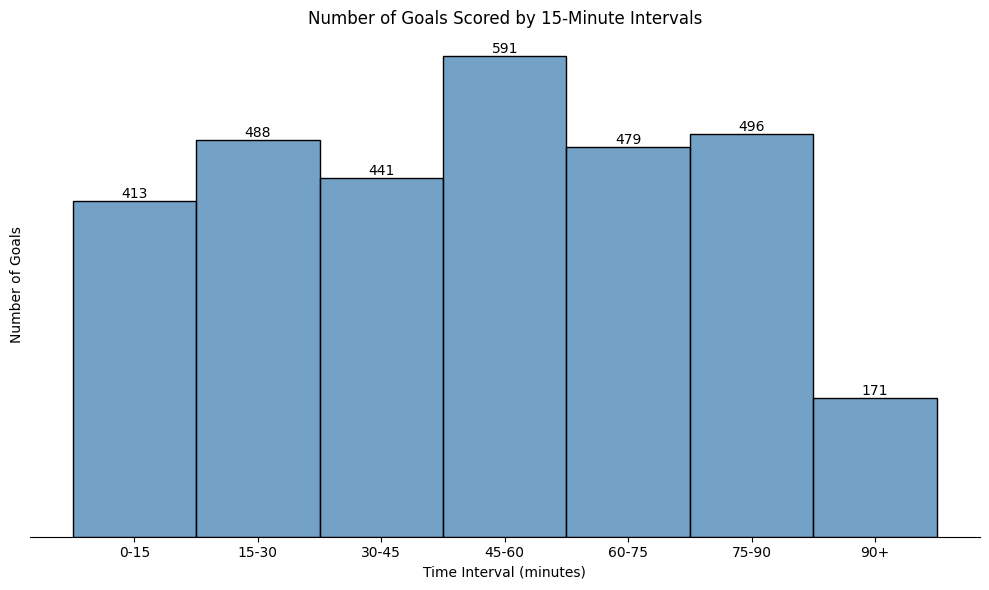

In [156]:
# Create bins for 15-minute intervals
bins = [0, 15, 30, 45, 60, 75, 90, 105]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+']

# Bin the goal_minute_num into 15-minute intervals
df['goal_interval'] = pd.cut(df['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='goal_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 15-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()

In [157]:
df['match_half'].value_counts()

match_half
Second Half    1691
First Half     1388
Name: count, dtype: int64

In [158]:
def classify_added_time(minute):
    if isinstance(minute, str):
        if minute.startswith('45+'):
            return 'First Half'
        elif minute.startswith('90+'):
            return 'Second Half'
    return np.nan

df['added_time_goal'] = df['goal_minute'].apply(classify_added_time)

In [159]:
df['added_time_goal'].value_counts()

added_time_goal
Second Half    128
First Half      62
Name: count, dtype: int64

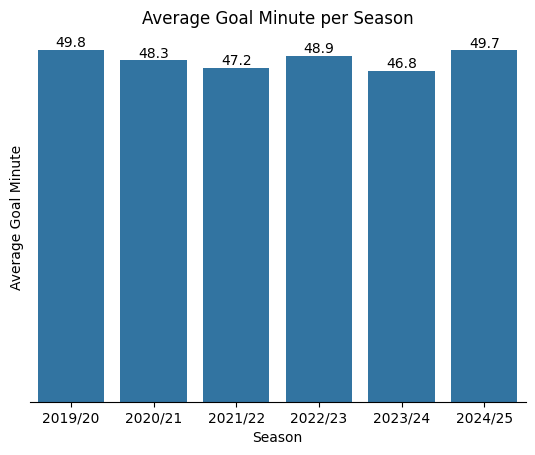

In [160]:
avg_goal_minute = (
    df.groupby('season', as_index=False)['goal_minute_num']
      .mean()
      .round(1)
)

ax = sns.barplot(data=avg_goal_minute, x='season', y='goal_minute_num');

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title("Average Goal Minute per Season")
plt.ylabel("Average Goal Minute")
plt.xlabel("Season")
plt.show()

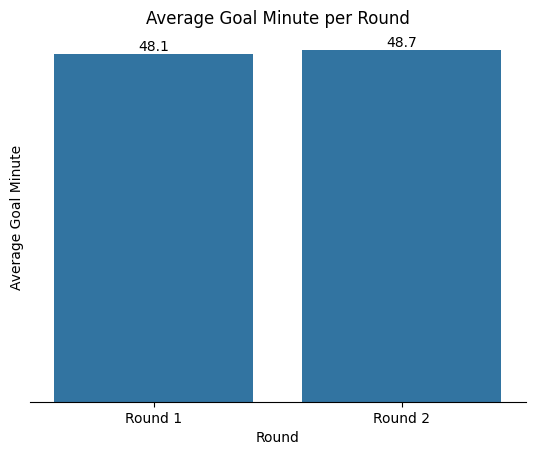

In [161]:
avg_goal_minute = (
    df.groupby('round', as_index=False)['goal_minute_num']
      .mean()
      .round(1)
)

ax = sns.barplot(data=avg_goal_minute, x='round', y='goal_minute_num');

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title("Average Goal Minute per Round")
plt.ylabel("Average Goal Minute")
plt.xlabel("Round")
plt.show()

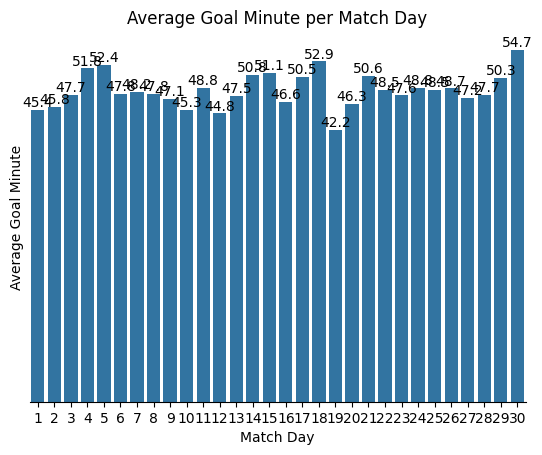

In [162]:
avg_goal_minute = (
    df.groupby('match_day', as_index=False)['goal_minute_num']
      .mean()
      .round(1)
)

ax = sns.barplot(data=avg_goal_minute, x='match_day', y='goal_minute_num');

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title("Average Goal Minute per Match Day")
plt.ylabel("Average Goal Minute")
plt.xlabel("Match Day")
plt.show()

In [163]:
df['team_side'].value_counts()

team_side
home    1812
away    1267
Name: count, dtype: int64

In [164]:
df.columns

Index(['date', 'time', 'season', 'match_day', 'home_team', 'away_team',
       'goal_minute', 'team_side', 'player_name', 'goal_type', 'has_goal',
       'goal_minute_num', 'in_added_time', 'match_id', 'round', 'match_half',
       'goal_interval', 'added_time_goal'],
      dtype='object')

In [165]:
df[['added_time_goal','in_added_time']]

,added_time_goal,in_added_time
0,NaN,0
1,NaN,0
2,Second Half,1
3,NaN,0
4,NaN,0
...,...,...
3217,NaN,0
3218,NaN,0
3219,NaN,0
3220,NaN,0


In [166]:
df['goal_type'].value_counts()

goal_type
Regular     2696
Penalty      319
Own Goal      64
Name: count, dtype: int64

In [167]:
df.groupby('team_side')['goal_type'].value_counts()

team_side  goal_type
away       Regular      1122
           Penalty       113
           Own Goal       32
home       Regular      1574
           Penalty       206
           Own Goal       32
Name: count, dtype: int64

In [168]:
df.groupby(['goal_type','match_half'])['goal_minute_num'].mean().round(2)

goal_type  match_half 
Own Goal   First Half     22.61
           Second Half    66.94
Penalty    First Half     23.34
           Second Half    69.80
Regular    First Half     23.14
           Second Half    69.07
Name: goal_minute_num, dtype: float64

In [169]:
df.groupby('goal_type')['match_half'].value_counts()

goal_type  match_half 
Own Goal   Second Half      36
           First Half       28
Penalty    Second Half     176
           First Half      143
Regular    Second Half    1479
           First Half     1217
Name: count, dtype: int64

In [170]:
df[df['match_half']=='Second Half']['goal_minute_num'].mean()

np.float64(69.09757539917209)

In [171]:
df[df['match_half']=='First Half']['goal_minute_num'].mean()

np.float64(23.146974063400577)

In [172]:
df[df['match_half']=='Second Half'].groupby('season')['goal_minute_num'].mean().round(2)

season
2019/20    71.05
2020/21    69.14
2021/22    68.52
2022/23    69.37
2023/24    68.02
2024/25    68.70
Name: goal_minute_num, dtype: float64

In [173]:
df[df['match_half']=='First Half'].groupby('season')['goal_minute_num'].mean().round(2)

season
2019/20    22.28
2020/21    23.40
2021/22    23.48
2022/23    22.64
2023/24    23.39
2024/25    23.37
Name: goal_minute_num, dtype: float64

In [174]:
df.groupby('season')['has_goal'].sum()

season
2019/20    453
2020/21    602
2021/22    574
2022/23    430
2023/24    513
2024/25    507
Name: has_goal, dtype: int64

## Team based insights

In [175]:
df[df['team_side'] == 'home'].groupby('home_team')['goal_minute_num'].mean().round(1).sort_values(ascending=False)

home_team
Mbale Heroes FC            68.8
Lugazi FC                  61.6
MYDA FC                    61.6
Mbarara City FC            54.9
Onduparaka FC              51.5
SC Villa                   51.5
NEC FC                     50.9
Kitara FC                  50.3
BUL FC                     49.4
Soltilo Bright Stars FC    49.2
Maroons FC                 49.0
Vipers SC                  48.9
URA FC                     48.4
KCCA FC                    48.3
Kyetume FC                 48.2
Police FC                  48.0
Entebbe UPPC FC            47.3
UPDF FC                    47.2
Busoga United FC           46.4
Tooro United FC            45.9
Wakiso Giants FC           45.7
Express FC                 44.3
Arua Hill SC               44.1
Proline FC                 42.3
Blacks Power FC            41.8
Name: goal_minute_num, dtype: float64

In [176]:
df[df['team_side'] == 'away'].groupby('away_team')['goal_minute_num'].mean().round(1).sort_values(ascending=False)

away_team
Tooro United FC            63.5
Mbarara City FC            54.7
Onduparaka FC              53.6
Kitara FC                  51.5
MYDA FC                    51.0
Express FC                 48.4
Entebbe UPPC FC            48.4
Wakiso Giants FC           48.3
KCCA FC                    48.1
Arua Hill SC               48.0
Busoga United FC           47.9
Maroons FC                 47.7
URA FC                     47.6
SC Villa                   47.4
Mbale Heroes FC            47.4
NEC FC                     47.1
UPDF FC                    47.1
Soltilo Bright Stars FC    46.5
Blacks Power FC            46.4
BUL FC                     46.4
Kyetume FC                 45.4
Vipers SC                  45.4
Police FC                  44.3
Lugazi FC                  38.3
Proline FC                 31.9
Name: goal_minute_num, dtype: float64

In [177]:
df[(df['match_half'] == 'Second Half') & (df['team_side'] == 'away')].groupby('away_team')['goal_minute_num'].mean().round(1).sort_values(ascending=False)

away_team
MYDA FC                    73.6
Onduparaka FC              72.4
Arua Hill SC               72.1
BUL FC                     71.6
Kitara FC                  71.0
Mbarara City FC            70.8
Tooro United FC            70.5
Proline FC                 70.0
KCCA FC                    69.4
Blacks Power FC            69.2
Maroons FC                 69.2
Busoga United FC           69.1
UPDF FC                    68.3
Wakiso Giants FC           68.3
Express FC                 68.1
URA FC                     68.0
SC Villa                   67.7
Entebbe UPPC FC            66.8
Kyetume FC                 66.7
Soltilo Bright Stars FC    66.6
Vipers SC                  66.4
Lugazi FC                  65.5
NEC FC                     65.4
Police FC                  65.1
Mbale Heroes FC            64.3
Name: goal_minute_num, dtype: float64

In [178]:
df[(df['match_half'] == 'First Half') & (df['team_side'] == 'away')].groupby('away_team')['goal_minute_num'].mean().round(1).sort_values(ascending=False)

away_team
Tooro United FC            33.0
MYDA FC                    32.2
Mbarara City FC            28.8
Wakiso Giants FC           25.5
KCCA FC                    25.0
Lugazi FC                  24.8
URA FC                     24.6
Express FC                 24.5
Entebbe UPPC FC            24.4
Busoga United FC           24.4
Police FC                  24.2
NEC FC                     24.0
Onduparaka FC              23.9
Blacks Power FC            23.5
Soltilo Bright Stars FC    23.3
Vipers SC                  22.9
Maroons FC                 22.6
SC Villa                   22.2
UPDF FC                    21.8
BUL FC                     21.2
Kyetume FC                 19.9
Proline FC                 19.2
Kitara FC                  19.2
Arua Hill SC               15.8
Mbale Heroes FC            13.7
Name: goal_minute_num, dtype: float64

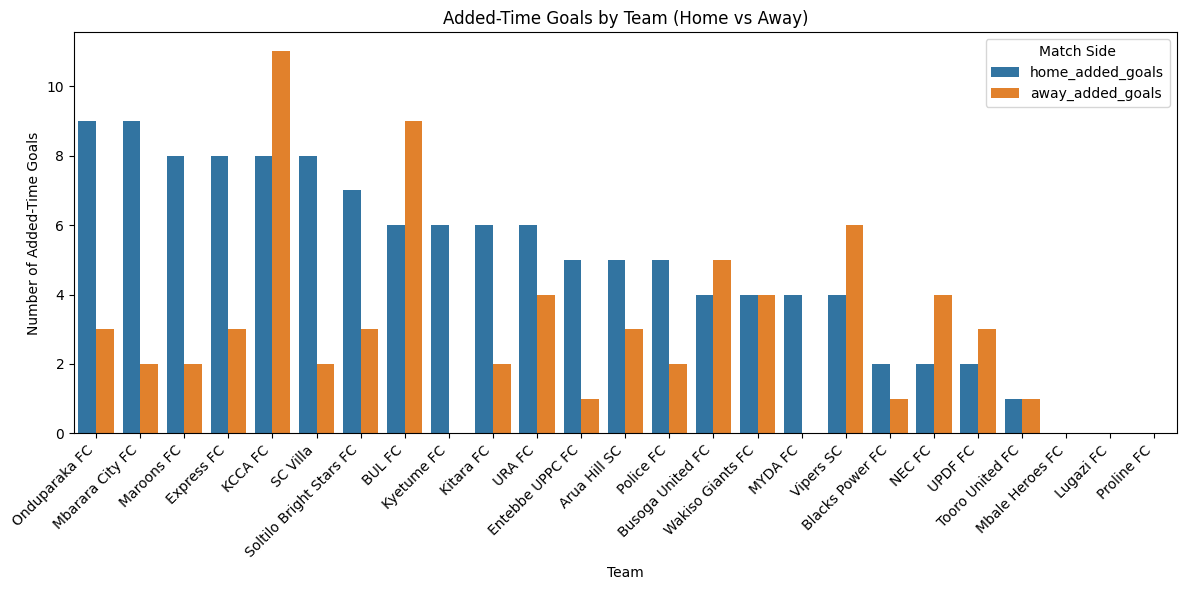

In [179]:
# Home teams
home_added = (
    df[df['team_side'] == 'home']
    .groupby('home_team')['in_added_time']
    .sum()
    .reset_index()
    .rename(columns={'home_team': 'team', 'in_added_time': 'home_added_goals'})
)

# Away teams
away_added = (
    df[df['team_side'] == 'away']
    .groupby('away_team')['in_added_time']
    .sum()
    .reset_index()
    .rename(columns={'away_team': 'team', 'in_added_time': 'away_added_goals'})
)


# Merge both
added_goals = pd.merge(home_added, away_added, on='team', how='outer').fillna(0)
added_goals['total_added_goals'] = added_goals['home_added_goals'] + added_goals['away_added_goals']

added_goals = added_goals.sort_values('home_added_goals', ascending=False)


added_goals_melted = added_goals.melt(
    id_vars='team',
    value_vars=['home_added_goals', 'away_added_goals'],
    var_name='Match Side',
    value_name='Added Time Goals'
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=added_goals_melted,
    x='team', y='Added Time Goals', hue='Match Side'
)
plt.title('Added-Time Goals by Team (Home vs Away)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Added-Time Goals')
plt.xlabel('Team')
plt.tight_layout()
plt.show()



In [180]:
df.columns

Index(['date', 'time', 'season', 'match_day', 'home_team', 'away_team',
       'goal_minute', 'team_side', 'player_name', 'goal_type', 'has_goal',
       'goal_minute_num', 'in_added_time', 'match_id', 'round', 'match_half',
       'goal_interval', 'added_time_goal'],
      dtype='object')

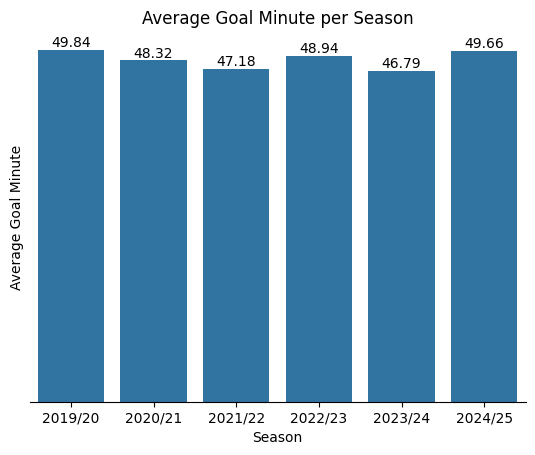

In [181]:
season_trend = (
    df.groupby('season')['goal_minute_num']
      .mean().round(2)
      .reset_index(name='avg_goal_min')
)

ax = sns.barplot(data=season_trend, x='season', y='avg_goal_min')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title("Average Goal Minute per Season")
plt.xlabel("Season")
plt.ylabel("Average Goal Minute")
plt.show()


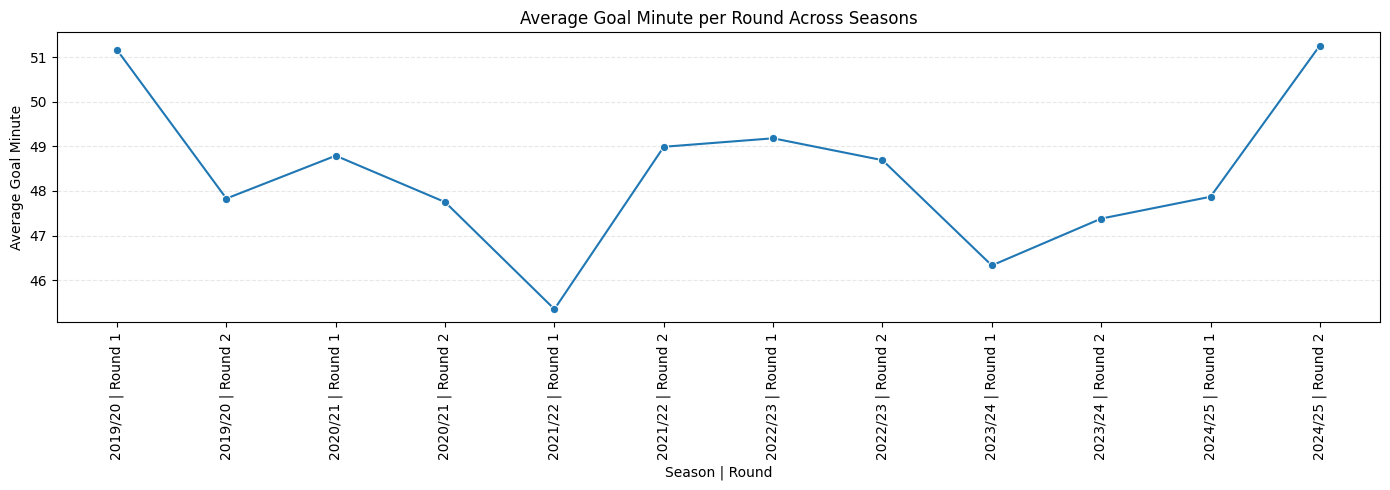

In [182]:


# --- PREPARE DATA ---
round_trend = (
    df.groupby(['season', 'round'])['goal_minute_num']
      .mean().round(2)
      .reset_index(name='avg_goal_min')
)

# Create a combined label for the x-axis
round_trend['season_round'] = round_trend['season'].astype(str) + " | " + round_trend['round'].astype(str)

# Sort chronologically by season, then round
round_trend = round_trend.sort_values(by=['season', 'round'])

# --- PLOT ---
plt.figure(figsize=(14,5))
sns.lineplot(data=round_trend, x='season_round', y='avg_goal_min', marker='o')

plt.title("Average Goal Minute per Round Across Seasons")
plt.xlabel("Season | Round")
plt.ylabel("Average Goal Minute")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [183]:




# --- PREPARE DATA ---
matchday_trend = (
    df.groupby(['season', 'match_day'])['goal_minute_num']
      .mean().round(2)
      .reset_index(name='avg_goal_min')
)

# Sort by season then match_day
matchday_trend = matchday_trend.sort_values(by=['season', 'match_day'])

# Numeric x-axis index
matchday_trend['x'] = range(len(matchday_trend))

# Smooth line
matchday_trend['smooth_avg'] = (
    matchday_trend['avg_goal_min'].rolling(window=3, center=True).mean()
)

# Colors for seasons
season_list = matchday_trend['season'].unique()
palette = px.colors.qualitative.Dark24
season_colors = {season: palette[i] for i, season in enumerate(season_list)}

# --- BUILD FIGURE ---
fig = go.Figure()

for season in season_list:
    subset = matchday_trend[matchday_trend['season'] == season]

    # Background shading (simulated with rectangle shapes)
    fig.add_shape(
        type="rect",
        x0=subset['x'].min(), x1=subset['x'].max(),
        y0=0, y1=1,
        xref="x", yref="paper",
        fillcolor=season_colors[season],
        opacity=0.15,
        layer="below",
        line_width=0,
    )

    # Trend line
    fig.add_trace(go.Scatter(
        x=subset['x'],
        y=subset['smooth_avg'],
        mode='lines+markers',
        name=str(season),
        line=dict(width=2, color=season_colors[season]),
        hovertemplate=
            "<b>Season:</b> %{customdata[0]}<br>" +
            "<b>Matchday:</b> %{customdata[1]}<br>" +
            "<b>Avg Goal Minute:</b> %{customdata[2]}<br>" +
            "<b>Smoothed:</b> %{y}<extra></extra>",
        customdata=subset[['season', 'match_day', 'avg_goal_min']].values
    ))

# --- LAYOUT ---
fig.update_layout(
    title="Interactive Average Goal Minute per Matchday Across Seasons",
    xaxis_title="Matchday (ordered, no labels)",
    yaxis_title="Average Goal Minute",
    xaxis=dict(showticklabels=False),
    plot_bgcolor="white",
    legend_title="Season",
    height=500,
)

fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor="lightgray")

fig.show()


In [184]:
df.groupby('time')['goal_minute_num'].mean().round(2).sort_values(ascending=False)

time
3:50 pm    69.25
4:11 pm    68.50
1:00 am    65.75
4:10 pm    63.40
4:35 pm    58.33
8:00 pm    53.86
2:00 pm    53.14
4:40 pm    53.00
1:00 pm    52.41
3:40 pm    51.75
4:30 pm    50.70
7:02 pm    49.40
7:00 pm    48.48
4:00 pm    48.46
1:25 pm    48.00
3:10 pm    46.67
3:00 pm    46.27
6:00 pm    45.62
5:20 pm    42.60
3:30 pm    42.53
5:00 pm    39.50
3:20 pm    39.00
4:20 pm    37.85
4:05 pm    36.60
6:30 pm    36.00
1:15 pm    35.00
4:45 pm    34.33
3:35 pm    29.50
4:55 pm    29.50
2:15 pm    29.00
1:10 pm    24.00
4:13 pm    22.50
4:03 pm    16.00
3:15 pm    15.00
4:50 pm     9.50
4:07 pm      NaN
4:14 pm      NaN
4:15 pm      NaN
4:43 pm      NaN
Name: goal_minute_num, dtype: float64

In [185]:
df['time'] = (
    df['time']
      .astype(str)
      .str.strip()                     # remove spaces
      .str.lower()                     # lower-case am/pm
      .str.replace(" ", "", regex=False) # remove any internal spaces
      .str.replace("am","pm",regex=False)# remove any poorly named matches (no matches were played in the morning during these seasons)
)


In [186]:
df['time_parsed'] = pd.to_datetime(df['time'], format='%I:%M%p', errors='coerce')


In [187]:
df[df['time_parsed'].isna()]['time'].unique()


array([], dtype=object)

In [188]:
mask = df['time'].str.startswith("12") & df['time'].str.endswith("pm")
df.loc[mask, 'time_parsed'] = (
    pd.to_datetime("12:" + df.loc[mask, 'time'].str[3:5] + "pm")
)


In [189]:
df['hour'] = df['time_parsed'].dt.hour


In [190]:
# Create hour label ranges
df['hour_range'] = df['hour'].apply(lambda h: f"{h}:00–{h+1}:00")


In [191]:
df['hour_range'].unique()

array(['16:00–17:00', '20:00–21:00', '15:00–16:00', '13:00–14:00',
       '17:00–18:00', '14:00–15:00', '19:00–20:00', '18:00–19:00'],
      dtype=object)

In [192]:
hourly_goal_trend = (
    df.groupby('hour_range')['goal_minute_num']
      .mean()
      .round(2)
      .reset_index()
)


In [193]:
# Extract integer hour again for sorting
hourly_goal_trend['hour'] = (
    hourly_goal_trend['hour_range']
    .str.extract(r'^(\d+):')[0]
    .astype(float)      # convert to float first to allow NaN
)

hourly_goal_trend = hourly_goal_trend.dropna(subset=['hour'])
hourly_goal_trend['hour'] = hourly_goal_trend['hour'].astype(int)
hourly_goal_trend = hourly_goal_trend.sort_values('hour')



In [194]:
df.columns

Index(['date', 'time', 'season', 'match_day', 'home_team', 'away_team',
       'goal_minute', 'team_side', 'player_name', 'goal_type', 'has_goal',
       'goal_minute_num', 'in_added_time', 'match_id', 'round', 'match_half',
       'goal_interval', 'added_time_goal', 'time_parsed', 'hour',
       'hour_range'],
      dtype='object')

In [195]:
df.groupby('goal_minute_num')['date'].count().sort_values(ascending=False)

goal_minute_num
46.0    59
47.0    47
80.0    47
45.0    46
52.0    46
        ..
96.0     6
95.0     5
97.0     3
98.0     1
99.0     1
Name: date, Length: 99, dtype: int64

In [196]:
df.columns

Index(['date', 'time', 'season', 'match_day', 'home_team', 'away_team',
       'goal_minute', 'team_side', 'player_name', 'goal_type', 'has_goal',
       'goal_minute_num', 'in_added_time', 'match_id', 'round', 'match_half',
       'goal_interval', 'added_time_goal', 'time_parsed', 'hour',
       'hour_range'],
      dtype='object')

In [197]:
# --- DATA CLEANING (CRITICAL) ---
# Ensure we can match 'Own Goal' regardless of capitalization (e.g., 'own goal', 'Own Goal', 'OG')
# Adjust 'Own Goal' string based on exactly what is in your scraped data
df['goal_type_clean'] = df['goal_type'].astype(str).str.lower().str.strip()
df['team_side_clean'] = df['team_side'].astype(str).str.lower().str.strip() 
# --- DEFINING THE CONDITIONS ---

# Condition 1: When does the HOME TEAM get a point?
# Case A: Home Team scores AND it is NOT an own goal
# Case B: Away Team scores AND it IS an own goal
home_point_conditions = [
    (df['team_side_clean'] == 'home') & (df['goal_type_clean'] != 'own goal'),
    (df['team_side_clean'] == 'away') & (df['goal_type_clean'] == 'own goal')
]

# Condition 2: When does the AWAY TEAM get a point?
# Case A: Away Team scores AND it is NOT an own goal
# Case B: Home Team scores AND it IS an own goal
away_point_conditions = [
    (df['team_side_clean'] == 'away') & (df['goal_type_clean'] != 'own goal'),
    (df['team_side_clean'] == 'home') & (df['goal_type_clean'] == 'own goal')
]

# --- APPLYING POINTS ---

# np.select(conditions, choices, default)
# If condition is met, give 1 point, otherwise 0
df['home_goal_flag'] = np.select(home_point_conditions, [1, 1], default=0)
df['away_goal_flag'] = np.select(away_point_conditions, [1, 1], default=0)

# --- CALCULATING SCORELINE (SAME AS BEFORE) ---

# Sort by Match and Minute first
# (Assuming you have already created 'minute_numeric' as discussed previously)
df = df.sort_values(by=['date', 'home_team', 'away_team', 'goal_minute_num'])

# Calculate Running Total
df['home_score_running'] = df.groupby(['date', 'home_team', 'away_team'])['home_goal_flag'].cumsum()
df['away_score_running'] = df.groupby(['date', 'home_team', 'away_team'])['away_goal_flag'].cumsum()

# Construct Scoreline
df['scoreline'] = df['home_score_running'].astype(str) + '-' + df['away_score_running'].astype(str)

# Verify with a quick look at Own Goals specifically
# print(df[df['goal_type_clean'] == 'own goal'][['home_team', 'away_team', 'team_side', 'goal_type', 'scoreline']].head())

In [198]:
df['scoreline'].value_counts()

scoreline
1-0    687
0-1    483
1-1    396
2-0    285
2-1    210
0-2    160
1-2    148
0-0    143
3-0    141
3-1     87
2-2     81
4-0     61
1-3     53
0-3     52
5-0     35
3-2     32
4-1     27
2-3     21
0-4     15
4-2     12
1-4     12
5-1     11
6-0     10
6-1      8
2-4      5
7-0      5
1-5      5
3-3      4
2-5      4
0-5      4
4-3      3
7-1      3
5-2      3
7-2      3
1-6      2
6-2      2
5-3      1
6-3      1
8-0      1
3-5      1
2-6      1
8-2      1
0-6      1
0-7      1
3-4      1
Name: count, dtype: int64

In [201]:
df[df['match_id'] == 'UPL22/MBA/TOO/14-05']

,date,time,season,match_day,home_team,away_team,goal_minute,team_side,player_name,goal_type,...,time_parsed,hour,hour_range,goal_type_clean,team_side_clean,home_goal_flag,away_goal_flag,home_score_running,away_score_running,scoreline
1272,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,5,home,Jude Ssemugabi,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,1,0,1-0
1273,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,12,home,Seiri Arigumaho,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,2,0,2-0
1274,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,24,home,Jude Ssemugabi,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,3,0,3-0
1275,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,31,away,Louis Mawa Bhoka,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,away,0,1,3,1,3-1
1276,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,44,home,Jude Ssemugabi,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,4,1,4-1
1277,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,55,home,Seiri Arigumaho,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,5,1,5-1
1278,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,69,home,Ronald Otti,Own Goal,...,1900-01-01 16:00:00,16,16:00–17:00,own goal,home,0,1,5,2,5-2
1279,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,76,home,Jude Ssemugabi,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,6,2,6-2
1280,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,83,home,Seiri Arigumaho,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,7,2,7-2
1281,2022-05-14,4:00pm,2021/22,29,Mbarara City FC,Tooro United FC,88,home,Henry Kitegenyi,Regular,...,1900-01-01 16:00:00,16,16:00–17:00,regular,home,1,0,8,2,8-2
